#### Data Augmentation ####

##### 1. Structured data

In [1]:
import pandas as pd
from sklearn.preprocessing import StandardScaler, OneHotEncoder

# Sample structured data
data = {'feature1': [1, 2, 3, None, 5], 
        'feature2': ['A', 'B', 'A', 'C', 'B'], 
        'target': [1, 2, 1.5, 2.5, 10]}
df = pd.DataFrame(data)

# Print original and transformed dataframes
print("Original Dataframe:\n", df.head())

# Handling Missing Values - Imputation
df['feature1'] = df['feature1'].fillna(df['feature1'].mean())

# Feature Engineering - Creating New Feature
df['feature3'] = df['feature1'] ** 2 

# Handling Outliers - Winsorization
# Winsorizing or winsorization is the transformation of statistics 
# by limiting extreme values in the statistical data to reduce the effect of possibly spurious outliers.
from scipy.stats.mstats import winsorize
df['target'] = winsorize(df['target'], limits=[0.1, 0.2]) 

# Encoding Categorical Features - One-Hot Encoding
encoder = OneHotEncoder()
encoded_features = encoder.fit_transform(df[['feature2']])
encoded_df = pd.DataFrame(encoded_features.toarray(), columns=encoder.get_feature_names_out(['feature2']))
df = pd.concat([df, encoded_df], axis=1)
df.drop('feature2', axis=1, inplace=True)

# Scaling and Normalization - Standardization
scaler = StandardScaler()
df[['feature1', 'feature3']] = scaler.fit_transform(df[['feature1', 'feature3']])

print("\nTransformed Dataframe:\n", df.head())

Original Dataframe:
    feature1 feature2  target
0       1.0        A     1.0
1       2.0        B     2.0
2       3.0        A     1.5
3       NaN        C     2.5
4       5.0        B    10.0

Transformed Dataframe:
    feature1  target  feature3  feature2_A  feature2_B  feature2_C
0 -1.322876     1.0 -0.998426         1.0         0.0         0.0
1 -0.566947     2.0 -0.638092         0.0         1.0         0.0
2  0.188982     1.5 -0.037535         1.0         0.0         0.0
3  0.000000     2.5 -0.210195         0.0         0.0         1.0
4  1.700840     2.5  1.884248         0.0         1.0         0.0


##### 2. Unstructured data - Image #####

New images can be created on the fly while training using "transforms"

In [2]:
from PIL import Image
from torchvision import transforms
from matplotlib import pyplot as plt
import warnings
warnings.filterwarnings('ignore')

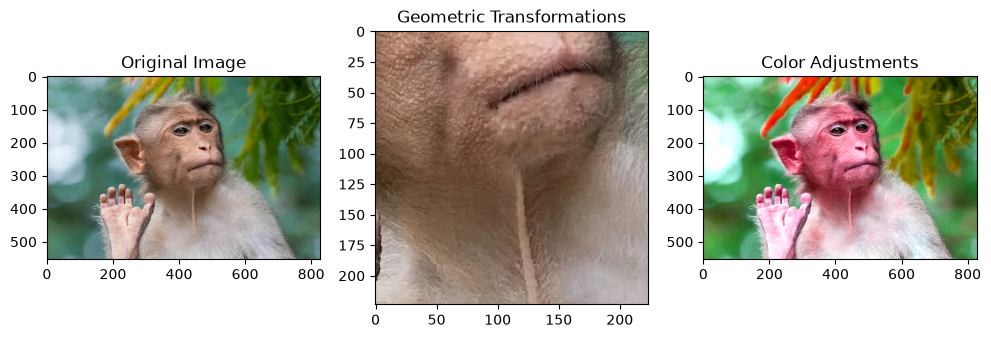

In [3]:
# Load an image
image = Image.open("Original_Image.jpeg")

# Geometric Transformations
transform_geometric = transforms.Compose([
    transforms.RandomHorizontalFlip(p=0.5),      # Flip horizontally with 50% probability
    transforms.RandomRotation(degrees=(-30, 30)), # Rotate between -30 and 30 degrees
    transforms.RandomCrop(size=(224, 224)),       # Crop to 224x224 randomly
])
augmented_image_geometric = transform_geometric(image)

# Color Space Adjustments
transform_color = transforms.Compose([
    transforms.ColorJitter(brightness=0.2, contrast=0.5, saturation=0.5, hue=0.1), # Adjust brightness, contrast, saturation, and hue
])
augmented_image_color = transform_color(image)

# Display original and augmented images
fig, axes = plt.subplots(1, 3, figsize=(12, 4))
axes[0].imshow(image)
axes[0].set_title("Original Image")
axes[1].imshow(augmented_image_geometric)
axes[1].set_title("Geometric Transformations")
axes[2].imshow(augmented_image_color)
axes[2].set_title("Color Adjustments")
plt.show()

##### Unstructured data - Text #####

New sentences can be crreated by using the synonyms of words

In [5]:
import random
from nltk.corpus import wordnet

word = "sad"
synonyms = []
for syn in wordnet.synsets(word):
    for lemma in syn.lemmas():
        synonyms.append(lemma.name())
print(f"Synonyms of '{word}': {set(synonyms)}") # Using set to avoid duplicates

def synonym_replacement(text, p=0.5):
    words = text.split()
    new_words = []
    for word in words:
        synonyms = wordnet.synsets(word)
        if synonyms and random.random() < p:
            # Ensure we get actual synonyms and not just the original word
            lemmas = [l.name() for s in synonyms for l in s.lemmas() if l.name() != word] 
            if lemmas:  # Check if we found any valid synonyms
                new_words.append(random.choice(lemmas))
            else:
                new_words.append(word)
        else:
            new_words.append(word)
    return " ".join(new_words)

text = "My happy childhood."
augmented_text = synonym_replacement(text)



print("Original Text:", text)
print("Augmented Text:", augmented_text)

Synonyms of 'sad': {'deplorable', 'distressing', 'lamentable', 'sorry', 'sad', 'pitiful'}
Original Text: My happy childhood.
Augmented Text: My well-chosen childhood.


##### 4. Unstructured data - Audio #####

Audi can be augmented with time stretching, pitch shifting and such transforms

In [6]:
# Note: Audio augmentation often requires specialized libraries like librosa or torchaudio. 
# The following is a conceptual illustration:

import librosa
import IPython.display as ipd

# Load audio
y, sr = librosa.load("acoustic_guitar.wav")

# Time Stretching
augmented_audio_time_stretch = librosa.effects.time_stretch(y, rate=1.2) 

# Pitch Shifting
augmented_audio_pitch_shift = librosa.effects.pitch_shift(y, sr=sr, n_steps=2)

# Play original audio
print("Original Audio:")
ipd.Audio(y, rate=sr)



Original Audio:


In [7]:
# Play time-stretched audio
print("\nTime Stretched Audio:")
ipd.Audio(augmented_audio_time_stretch, rate=sr)




Time Stretched Audio:


In [8]:
# Play pitch-shifted audio
print("\nPitch Shifted Audio:")
ipd.Audio(augmented_audio_pitch_shift, rate=sr)


Pitch Shifted Audio:
